# Lab 1

## Estimating worst-case/average-case complexity of algorithms via linear and binary search.

### 1. Linear Search

In [1]:
import math, random
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

n = 0 # no. of iterations

In [2]:
def linearSearch(arr, q):
    global n
    for i in range(1, len(arr)):
        n = n + 1
        if (arr[i] == q):
            return i

In [3]:
def testLinearSearch(num, maxRandLimit):
    # Build Data
    arr = []
    global n
    n = 0
    for i in range(0,num):
        arr.append(random.randint(0,maxRandLimit))
    q=random.randint(0,maxRandLimit)
    # Run the algorithm
    linearSearch(arr,q)
    return n

In [4]:
def run_n_times(iterations, sample_size):
    results = [0 for i in range(sample_size)]
    test_sizes = [10**i for i in range(1,sample_size+1)]
    for i in range(iterations):
        for j in range(len(test_sizes)):
            results[j] += testLinearSearch(test_sizes[j], test_sizes[j])
    for i in range(len(results)):
        results[i] = results[i]//iterations
    return results

In [5]:
ITER_RUNS = 5
RUN_SIZE = 4
results = run_n_times(ITER_RUNS, RUN_SIZE)

In [6]:
results

[3, 55, 664, 5657]

<function matplotlib.pyplot.show(close=None, block=None)>

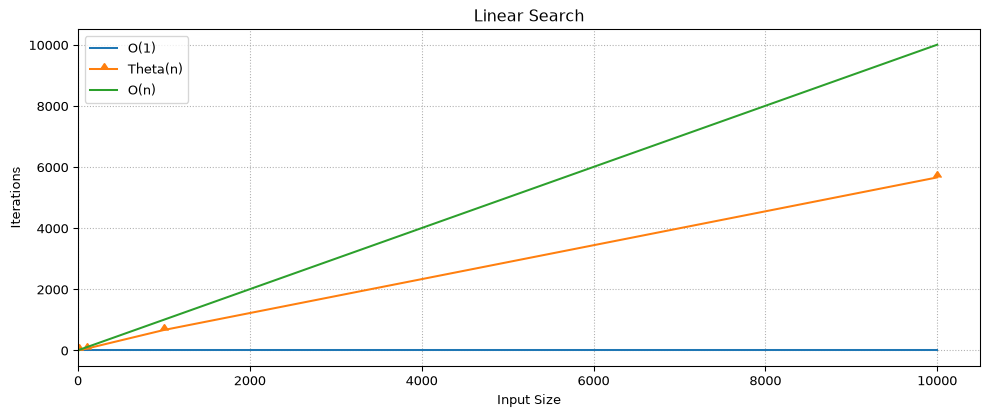

In [7]:
figure(figsize=(12, 4.5), dpi=97)

x = [10**(i+1) for i in range(RUN_SIZE)]
y1 = [1 for i in range(RUN_SIZE)] # best case
y2 = results[:RUN_SIZE] # avg case
y3 = [10**(i+1) for i in range(RUN_SIZE)] # worst case

plt.plot(x, y1, label="O(1)")
plt.plot(x, y2, label="Theta(n)", marker=10)
plt.plot(x, y3, label="O(n)")

plt.xlim(left=0)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("Iterations")
plt.title("Linear Search")
plt.grid(visible=True, linestyle=':')
plt.show

### 2. Binary Search

In [8]:
n=0
def binarySearch(arr, q, low, high):
    global n
    if (low > high) or ((low == high) and (q != low)) or (high >= len(arr)):
        return None
    mid = int((high - low)//2) + low
    if arr[mid] == q:
        n += 1
        return mid
    if q < arr[mid]:
        n += 1
        return binarySearch(arr, q, low, mid-1)
    if q > arr[mid]:
        n += 1
        return binarySearch(arr, q, mid+1, high)
    return None

In [9]:
def testBinarySearch(num, maxRandLimit):
    # Build Data
    arr = []
    global n
    n = 0
    for i in range(0,num):
        arr.append(random.randint(0,maxRandLimit))
    q=random.randint(0,maxRandLimit)
    # Run the algorithm
    binarySearch(arr,q,0,num-1)
    return n

In [10]:
def run_n_times_bst(iterations, sample_size):
    results = [0 for i in range(sample_size)]
    test_sizes = [10**i for i in range(1,sample_size+1)]
    for i in range(iterations):
        for j in range(len(test_sizes)):
            results[j] += testBinarySearch(test_sizes[j], test_sizes[j])
    for i in range(len(results)):
        results[i] = results[i]//iterations
    return results

In [11]:
ITER_RUNS = 5
RUN_SIZE = 4
results_b = run_n_times_bst(ITER_RUNS, RUN_SIZE)

In [12]:
results_b

[2, 5, 9, 12]

<function matplotlib.pyplot.show(close=None, block=None)>

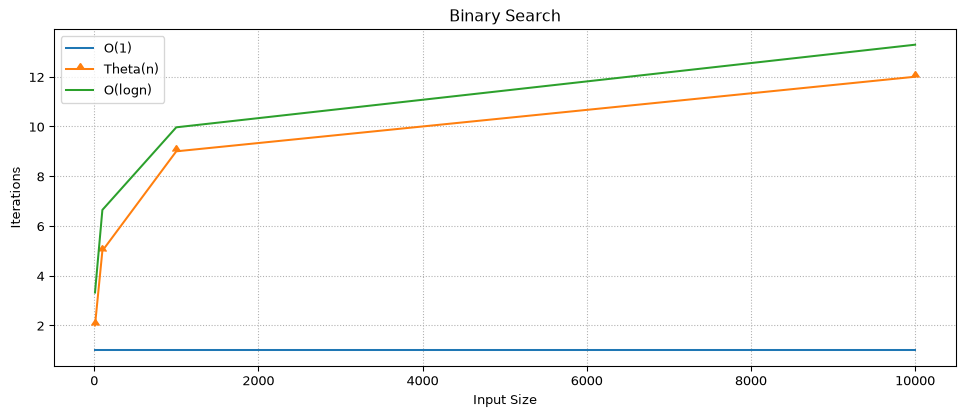

In [13]:
figure(figsize=(12, 4.5), dpi=97)

x = [10**(i+1) for i in range(RUN_SIZE)]
y1 = [1 for i in range(RUN_SIZE)] # best case
y2 = results_b[:RUN_SIZE] # avg case
y3 = [math.log2(i) for i in[10**(i+1) for i in range(RUN_SIZE)]] # worst case

plt.plot(x, y1, label="O(1)")
plt.plot(x, y2, label="Theta(n)", marker=10)
plt.plot(x, y3, label="O(logn)")

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("Iterations")
plt.title("Binary Search")
plt.grid(visible=True, linestyle=':')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

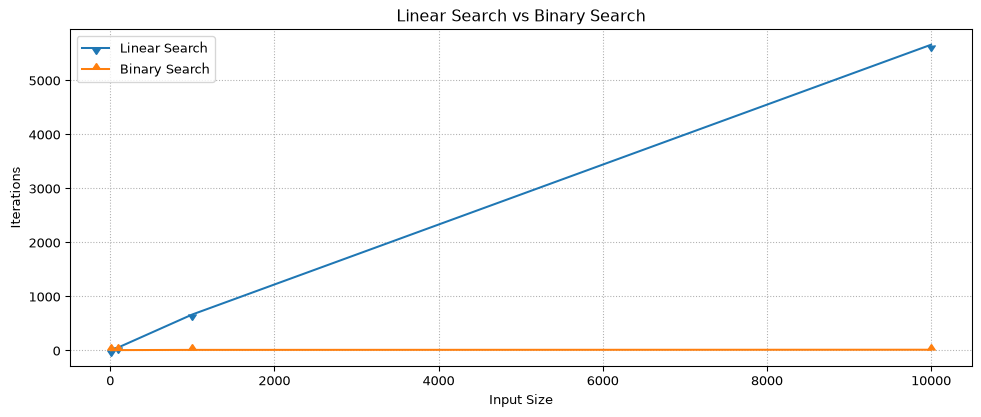

In [14]:
figure(figsize=(12, 4.5), dpi=97)

x = [10**(i+1) for i in range(RUN_SIZE)]
y1 = results[:RUN_SIZE] # Linear Search
y2 = results_b[:RUN_SIZE] # Binary Search

plt.plot(x, y1, label="Linear Search", marker=11)
plt.plot(x, y2, label="Binary Search", marker=10)
# plt.ylim(top=1000)
plt.legend()
plt.xlabel("Input Size")
plt.ylabel("Iterations")
plt.title("Linear Search vs Binary Search")
plt.grid(visible=True, linestyle=':')
plt.show